In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ------------------------------
# Hyperparameters
# ------------------------------
max_words = 10000
num_classes = 5  # number of BBC categories
max_len = 200

# ------------------------------
# Build the model
# ------------------------------
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),  # embedding layer
    LSTM(64),                                        # LSTM layer
    Dropout(0.5),                                    # dropout for regularization
    Dense(64, activation='relu'),                    # fully connected layer
    Dense(num_classes, activation='softmax')         # output layer
])

# ------------------------------
# Compile the model
# ------------------------------
model.compile(
    loss='sparse_categorical_crossentropy',  # if labels are integers
    optimizer='adam',
    metrics=['accuracy']
)

# ------------------------------
# Now you can train the model
# ------------------------------
# X_train_padded = pad_sequences(...)
# y_train = label encoded labels
# model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2)

# ------------------------------
# Save model in Keras 3 format
# ------------------------------
model.save("bbc_lstm_model.keras")


In [32]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM,SimpleRNN
from keras.optimizers import RMSprop
import numpy as np
import random
import sys
import pandas as pd
from wheel.macosx_libfile import read_data


In [33]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to C:\Users\mohamed
[nltk_data]     ezzat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
import sys
print(sys.executable)


C:\Users\mohamed ezzat\Downloads\RNN Mai\.venv\Scripts\python.exe


In [35]:
!where python

C:\Users\mohamed ezzat\.venv1\Scripts\python.exe
C:\Users\mohamed ezzat\AppData\Local\Programs\Python\Python312\python.exe
C:\Users\mohamed ezzat\AppData\Local\Programs\Python\Python310\python.exe
C:\Users\mohamed ezzat\AppData\Local\Programs\Python\Python313\python.exe
C:\Users\mohamed ezzat\AppData\Local\Microsoft\WindowsApps\python.exe


In [36]:
!pip install nltk


  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached regex-2025.11.3-cp310-cp310-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)
Using cached regex-2025.11.3-cp310-cp310-win_amd64.whl (277 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)

   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [joblib]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ----------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
data = pd.read_csv("bbc-text (1) (1).csv")

data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [38]:
data.shape

(2225, 2)

In [39]:
data.columns

Index(['category', 'text'], dtype='object')

In [40]:
data.isnull().sum()

category    0
text        0
dtype: int64

In [41]:
texts = data['text'].apply(lambda x: x.lower()) # convert 'text' col to lowercase

labels, unique_categories = pd.factorize(data['category']) # convert labels (category) to numeric using factorize

print("Categories:", unique_categories)
print("First 5 labels:", labels[:5])


Categories: Index(['tech', 'business', 'sport', 'entertainment', 'politics'], dtype='object')
First 5 labels: [0 1 2 2 3]


In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# ensure that all input sequences have the same length, which is necessary for RNNs, LSTMs, and GRUs (sequence -> a list of integers representing a text
tokenizer = Tokenizer(num_words=10000)  # keep top 10000 words


In [43]:
tokenizer.fit_on_texts(texts) # this step scans all the text in your dataset and builds a word index dictionary
# Each word gets a unique integer ID
# Example: {'the': 1, 'and': 2, 'movie': 3, ...}

In [44]:
sequences = tokenizer.texts_to_sequences(texts)
# now, each sentence is converted into a sequence of numbers
# Example: "I love this movie" → [45, 120, 8, 67]
# This numeric representation can now be used as input to neural networks

In [45]:
X = pad_sequences(sequences, maxlen=200) # maxlen can be adjusted

In [46]:
y = np.array(labels)

- Machine learning models expect numpy arrays as input and output.

- labels were a list of integers (from pd.factorize()), now we convert them to a numpy array for compatibility.

In [47]:
print('Shape of X:', X.shape) # no. of samples and sequence len
print('Shape of y:', y.shape) # no. of labels


Shape of X: (2225, 200)
Shape of y: (2225,)


In [48]:
 # ------------------------------
# 1) Imports
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

le = LabelEncoder()
y = le.fit_transform(data['category'])  # Converts category names to integers
num_classes = len(le.classes_)


In [49]:
# ------------------------------
# 4) Train-Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], y, test_size=0.2, random_state=42, stratify=y
)


In [50]:
# ------------------------------
# 5) Tokenization & Padding
# ------------------------------
max_words = 10000   # Vocabulary size
max_len = 200       # Max length of sequences

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')


In [51]:
# ------------------------------
# 6) Build RNN Model
# ------------------------------
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 200, 128)          1280000   
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, 64)                12352     
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_10 (Dense)            (None, 64)                4160      
                                                                 
 dense_11 (Dense)            (None, 5)                 325       
                                                                 
Total params: 1296837 (4.95 MB)
Trainable params: 1296837 (4.95 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [52]:
# ------------------------------
# 7) Train RNN
# ------------------------------
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
23/23 [==============================] - 3s 69ms/step - loss: 1.6116 - accuracy: 0.2254 - val_loss: 1.5777 - val_accuracy: 0.3062
Epoch 2/10
23/23 [==============================] - 1s 62ms/step - loss: 1.4368 - accuracy: 0.4635 - val_loss: 1.5271 - val_accuracy: 0.3596
Epoch 3/10
23/23 [==============================] - 1s 57ms/step - loss: 1.1512 - accuracy: 0.6566 - val_loss: 1.2843 - val_accuracy: 0.4663
Epoch 4/10
23/23 [==============================] - 1s 57ms/step - loss: 0.7745 - accuracy: 0.8062 - val_loss: 1.2047 - val_accuracy: 0.4860
Epoch 5/10
23/23 [==============================] - 1s 57ms/step - loss: 0.4128 - accuracy: 0.9228 - val_loss: 1.2812 - val_accuracy: 0.4888
Epoch 6/10
23/23 [==============================] - 1s 56ms/step - loss: 0.1734 - accuracy: 0.9824 - val_loss: 1.3337 - val_accuracy: 0.4944
Epoch 7/10
23/23 [==============================] - 1s 55ms/step - loss: 0.0656 - accuracy: 0.9986 - val_loss: 1.3995 - val_accuracy: 0.4719
Epoch 8/10
23

14/14 [==============================] - 0s 10ms/step - loss: 2.0685 - accuracy: 0.3528
RNN Test Loss: 2.068523645401001
RNN Test Accuracy: 0.35280898213386536
14/14 [==============================] - 0s 11ms/step
               precision    recall  f1-score   support

     business       0.18      0.14      0.15       102
entertainment       0.31      0.21      0.25        77
     politics       0.22      0.21      0.22        84
        sport       0.62      0.57      0.59       102
         tech       0.37      0.64      0.47        80

     accuracy                           0.35       445
    macro avg       0.34      0.35      0.34       445
 weighted avg       0.34      0.35      0.34       445



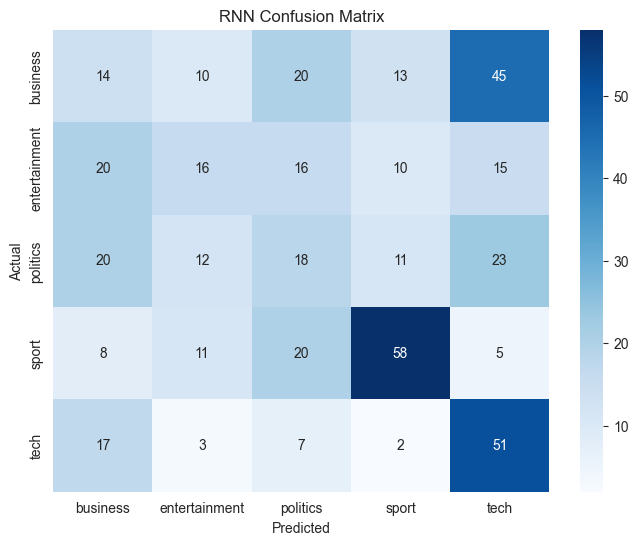

In [53]:
# ------------------------------
# 8) Evaluate RNN
# ------------------------------
rnn_eval = rnn_model.evaluate(X_test_pad, y_test)
print("RNN Test Loss:", rnn_eval[0])
print("RNN Test Accuracy:", rnn_eval[1])

# Predictions
y_pred_rnn = np.argmax(rnn_model.predict(X_test_pad), axis=1)

# Classification Report
print(classification_report(y_test, y_pred_rnn, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")
plt.show()


In [54]:
# ------------------------------
# 9) Build LSTM Model
# ------------------------------
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 200, 128)          1280000   
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_6 (Dropout)         (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 64)                4160      
                                                                 
 dense_13 (Dense)            (None, 5)                 325       
                                                                 
Total params: 1333893 (5.09 MB)
Trainable params: 1333893 (5.09 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [55]:
# ------------------------------
# 10) Train LSTM
# ------------------------------
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
23/23 [==============================] - 5s 145ms/step - loss: 1.5957 - accuracy: 0.2549 - val_loss: 1.5804 - val_accuracy: 0.2135
Epoch 2/10
23/23 [==============================] - 3s 127ms/step - loss: 1.4218 - accuracy: 0.3490 - val_loss: 1.3180 - val_accuracy: 0.5112
Epoch 3/10
23/23 [==============================] - 3s 127ms/step - loss: 1.2306 - accuracy: 0.4600 - val_loss: 1.2456 - val_accuracy: 0.4607
Epoch 4/10
23/23 [==============================] - 3s 124ms/step - loss: 1.0955 - accuracy: 0.5681 - val_loss: 1.1174 - val_accuracy: 0.5112
Epoch 5/10
23/23 [==============================] - 3s 122ms/step - loss: 0.8704 - accuracy: 0.6468 - val_loss: 1.1847 - val_accuracy: 0.5899
Epoch 6/10
23/23 [==============================] - 3s 121ms/step - loss: 0.8251 - accuracy: 0.7156 - val_loss: 0.8818 - val_accuracy: 0.6124
Epoch 7/10
23/23 [==============================] - 3s 121ms/step - loss: 0.8464 - accuracy: 0.7170 - val_loss: 0.9364 - val_accuracy: 0.6404
Epoch 

14/14 [==============================] - 0s 22ms/step - loss: 0.6595 - accuracy: 0.8090
LSTM Test Loss: 0.6594735383987427
LSTM Test Accuracy: 0.8089887499809265
14/14 [==============================] - 1s 24ms/step
               precision    recall  f1-score   support

     business       0.93      0.63      0.75       102
entertainment       0.76      0.92      0.84        77
     politics       0.64      0.80      0.71        84
        sport       0.82      0.91      0.87       102
         tech       0.98      0.81      0.89        80

     accuracy                           0.81       445
    macro avg       0.83      0.81      0.81       445
 weighted avg       0.83      0.81      0.81       445



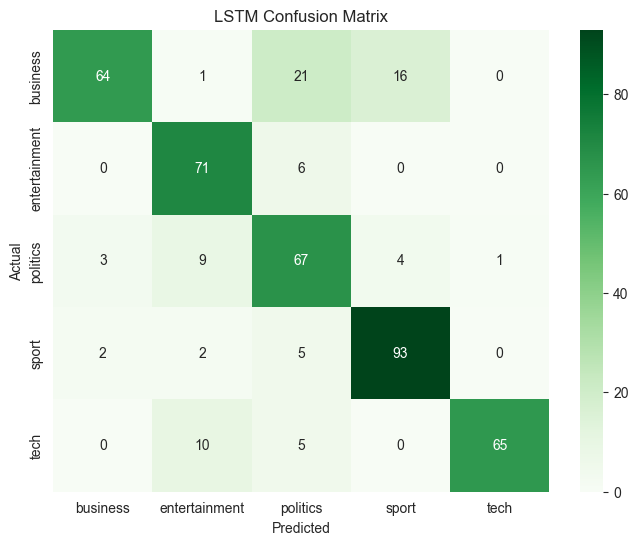

In [56]:
# ------------------------------
# 11) Evaluate LSTM
# ------------------------------
lstm_eval = lstm_model.evaluate(X_test_pad, y_test)
print("LSTM Test Loss:", lstm_eval[0])
print("LSTM Test Accuracy:", lstm_eval[1])

# Predictions
y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad), axis=1)

# Classification Report
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()


In [57]:
# Save LSTM model in Keras 3 format
lstm_model.save("bbc_lstm_model.keras")


In [1]:
!pip install opencv-python

  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 3.0 MB/s eta 0:00:14
   - -------------------------------------- 1.8/40.2 MB 3.5 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/40.2 MB 3.6 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/40.2 MB 3.7 MB/s eta 0:00:11
   ---- ----------------------------------- 4.2/40.2 MB 3.8 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/40.2 MB 3.8 MB/s eta 0:00:10
   ----- ---------------------------------- 5.8/40.2 MB 3.8 MB/s eta 0:00:10
   ------ --------------------------------- 6.8/40.2 MB 3.8 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/40.2 MB 3.8 MB/s eta 0:00:09
   ------- -------------------------------- 7.3/40.2 MB 3.8 MB/s eta 0:00:09
   -------- --------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
